In [1]:
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
from astropy.constants import GM_sun, c
from scipy.interpolate import CubicSpline
from multiprocessing import Pool, cpu_count
from scipy.signal import argrelextrema, savgol_filter
from gwrompy.utils import find_t_location, detrend_data

No version information file '.version' found


### Making an array of mean anomaly

In [2]:
mean_anomaly_array = np.linspace(-np.pi, np.pi, 80, endpoint=True)

### Defining priors

In [3]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.1
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400.

f_low = 10. 
delta_t = 1/2**18

### Defining geomterized time scale

In [4]:
t0 = GM_sun*(m1+ m2)/(c*c*c)

### Generating a reference waveform and visualizing

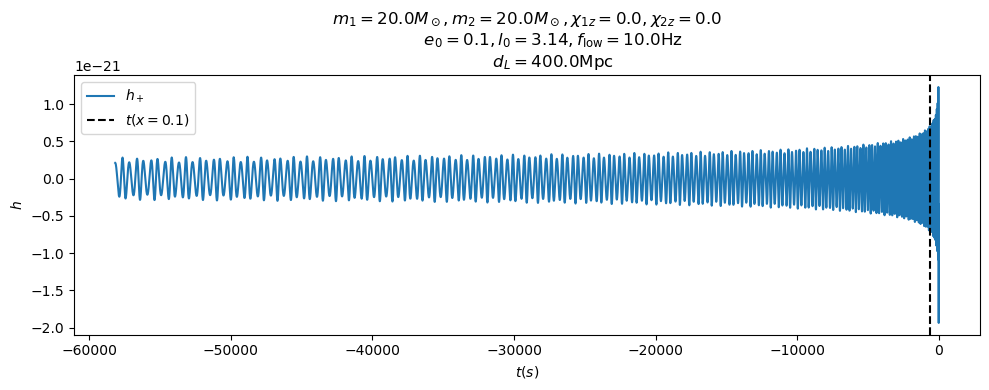

In [5]:
orb_vars, ref_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x', 'l'])

ref_signal = ref_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
plt.plot(ref_signal.sample_times/t0, ref_signal.real(), label=r"$h_+$")
plt.axvline(find_t_location(orb_vars['x'].sample_times / t0, orb_vars['x'].data, 0.1), color='k', linestyle='--', label=r"$t(x=0.1)$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

### Running simulation once to find minimum and maximum of the common time grid

In [6]:
t_val_min_array = []
t_val_max_array = []

for i in mean_anomaly_array:
    simulated_orb_vars, mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                            mass2=m2,
                                            spin1z=spin1z, 
                                            spin2z=spin2z,
                                            eccentricity=eccentricity,
                                            mean_anomaly=i,
                                            distance=distance,
                                            f_lower=f_low,
                                            delta_t=delta_t,
                                            include_conjugate_modes=False,
                                            modes_to_use=modes_to_use,
                                            return_orbital_params=['x'])
    
    t_val_min_pointer = find_t_location(simulated_orb_vars['x'].sample_times / t0, simulated_orb_vars['x'].data, simulated_orb_vars['x'].data[100])
    t_val_max_pointer = find_t_location(simulated_orb_vars['x'].sample_times / t0, simulated_orb_vars['x'].data, 0.1)

    t_val_min_pointer -= t_val_max_pointer
    t_val_min_array.append(t_val_min_pointer)

t_val_min = np.max(t_val_min_array)

In [7]:
# common_time_grid = np.arange(t_val_min, 0, (delta_t / t0.value) * 20)
common_time_grid = np.linspace(t_val_min, 0, 20_000, endpoint=True)

### Performing SVD of waveform matrix

In [8]:
X_waveform = np.zeros((len(mean_anomaly_array), len(common_time_grid)), dtype=complex)

In [9]:
def compute_waveform(mean_anomaly):
    test_orb_vars, test_modes = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use,
        return_orbital_params=['x']
    )

    test_signal = test_modes[(2, 2)]

    test_time = np.array([i.value for i in test_signal.sample_times / t0])
    t_0 = find_t_location(test_orb_vars['x'].sample_times / t0, test_orb_vars['x'].data, 0.1)
    test_time -= t_0
    signal_amp = np.abs(test_signal)
    signal_phase = np.unwrap(np.angle(test_signal))

    amp_spline = CubicSpline(test_time, signal_amp)
    test_sample_amp = amp_spline(common_time_grid)
    phase_spline = CubicSpline(test_time, signal_phase)
    test_sample_phase = phase_spline(common_time_grid)
    test_sample_phase -= test_sample_phase[0]

    test_sample_aligned = test_sample_amp * np.exp(1j * test_sample_phase)
    return test_sample_aligned

if __name__ == '__main__':
    nproc = min(cpu_count(), len(mean_anomaly_array)) 
    with Pool(processes=nproc) as pool:
        results = pool.map(compute_waveform, mean_anomaly_array)

    X_waveform = np.vstack(results)


In [10]:
U, s, Vt = np.linalg.svd(X_waveform, full_matrices=False)

### Extracting harmonics

In [11]:
eccentric_harmonics = {}
indices = np.arange(10)
indices = np.delete(indices, 2)
indices

array([0, 1, 3, 4, 5, 6, 7, 8, 9])

In [12]:
eccentric_harmonics = {}

waveform_j2 = s[0] * Vt[0]
phase_j2 = np.unwrap(np.angle(waveform_j2))
dt = np.abs(common_time_grid[1] - common_time_grid[0])
freq_22_2 = np.gradient(phase_j2, dt) / np.pi
f_orb = 0.5 * freq_22_2

eccentric_harmonics[2] = waveform_j2

num_bases_to_check = 10
for i in range(1, num_bases_to_check):
    waveform = s[i] * Vt[i]
    phase = np.unwrap(np.angle(waveform))
    freq_22_j = np.gradient(phase, dt) / np.pi

    j_index = round(freq_22_j[0] / f_orb[0])

    if j_index > 0 and j_index not in eccentric_harmonics:
        print(f"SVD basis i={i} corresponds to harmonic j={j_index}")
        eccentric_harmonics[j_index] = waveform

sorted_harmonics = dict(sorted(eccentric_harmonics.items()))

SVD basis i=1 corresponds to harmonic j=3
SVD basis i=2 corresponds to harmonic j=1
SVD basis i=3 corresponds to harmonic j=4
SVD basis i=4 corresponds to harmonic j=5
SVD basis i=6 corresponds to harmonic j=6
SVD basis i=9 corresponds to harmonic j=19


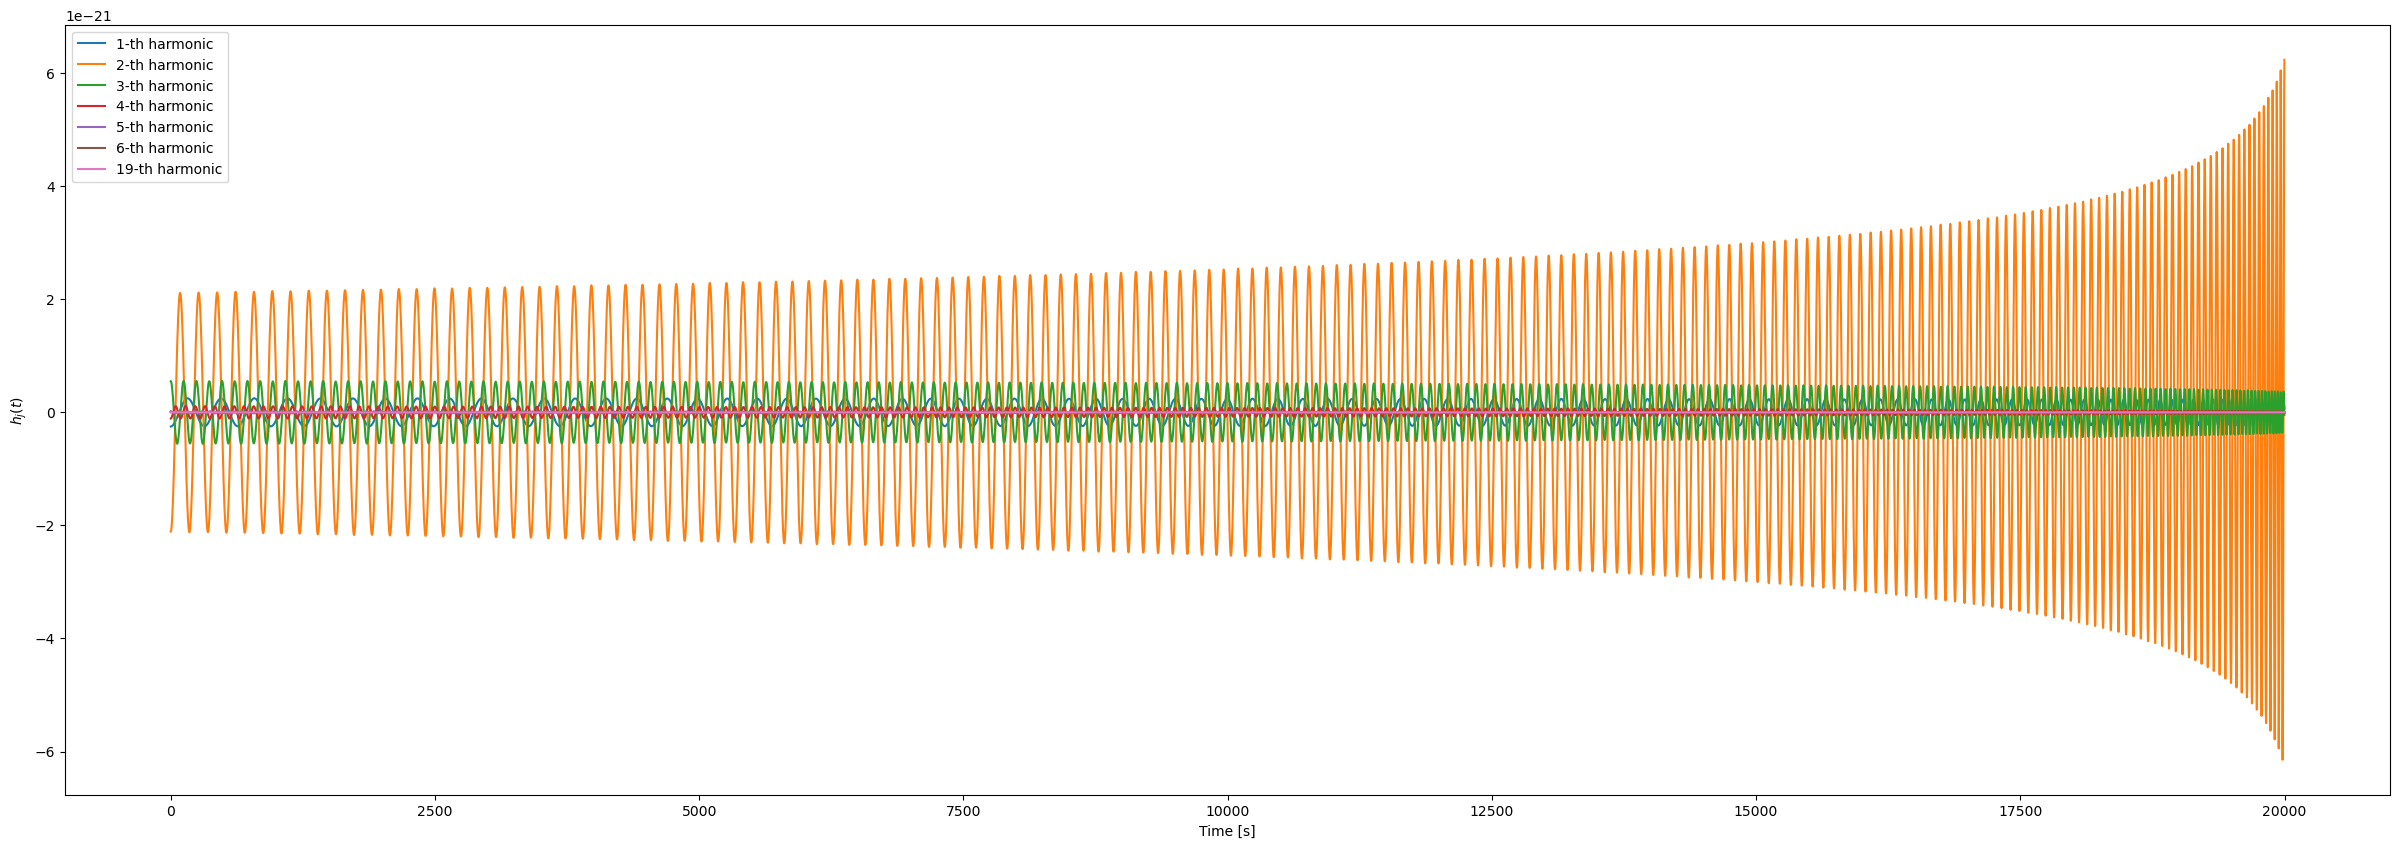

In [13]:
plt.figure(figsize=(30, 10))

for j_index, waveform in sorted_harmonics.items():
        plt.plot(waveform.real, label=f'{j_index}-th harmonic')
plt.ylabel('$h_j(t)$')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

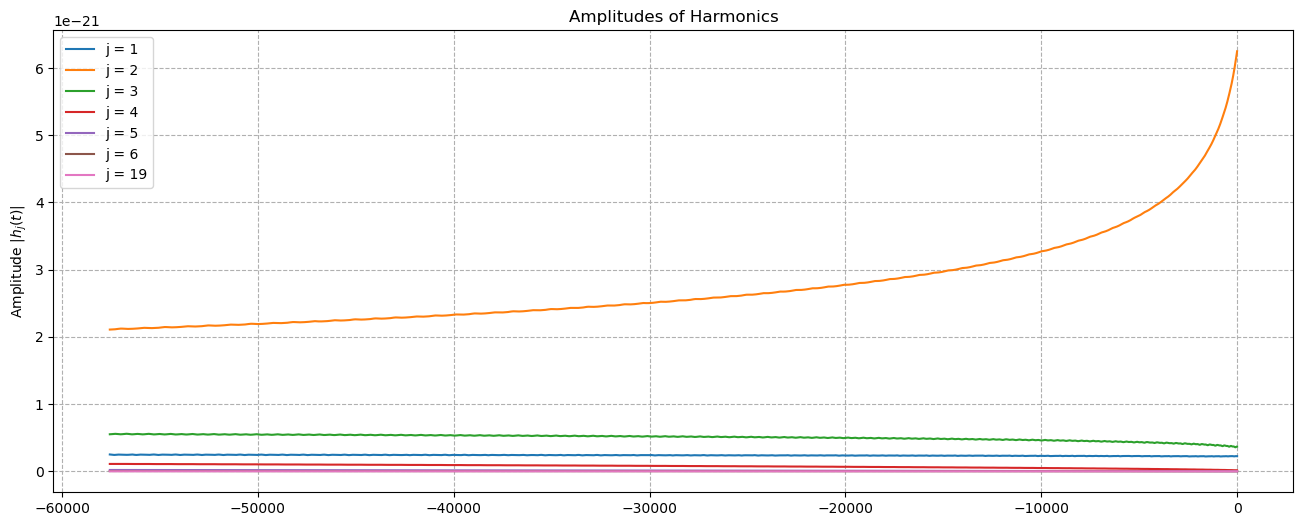

In [14]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    amp = np.abs(waveform)
    plt.plot(common_time_grid, amp, label=f'j = {j_index}')
# plt.yscale('log')
plt.ylabel('Amplitude |$h_j(t)$|')
plt.title('Amplitudes of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

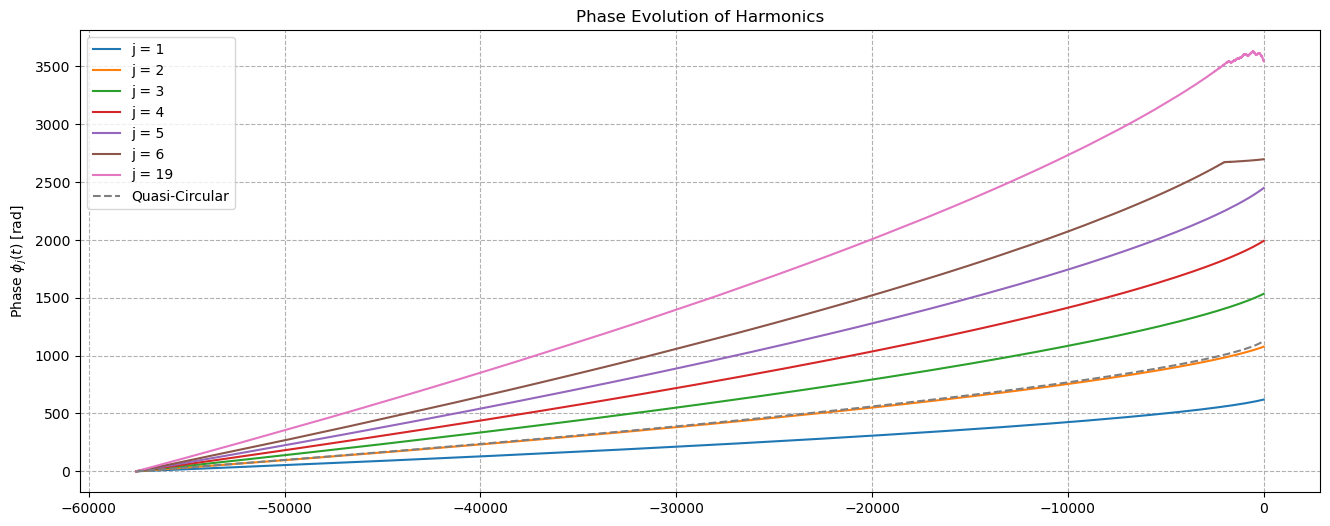

In [15]:
qc_orb_vars, qc_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=0,
                                        mean_anomaly=0,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x'])

qc_signal = qc_mode[(2,2)]

qc_signal_amp = np.abs(qc_signal)
qc_signal_phase = np.unwrap(np.angle(qc_signal))

qc_time = np.array([i.value for i in qc_signal.sample_times / t0])
t_0 = find_t_location(qc_orb_vars['x'].sample_times / t0, qc_orb_vars['x'].data, 0.1)
qc_time -= t_0

qc_signal_amp_spline = CubicSpline(qc_signal.sample_times / t0, qc_signal_amp)
qc_signal_phase_spline = CubicSpline(qc_signal.sample_times / t0, qc_signal_phase)

qc_signal_amp_reco = qc_signal_amp_spline(common_time_grid)
qc_signal_phase_reco = qc_signal_phase_spline(common_time_grid)

qc_signal_phase_reco = qc_signal_phase_reco - qc_signal_phase_reco[0]

qc_signal_reco = qc_signal_amp_reco * np.exp(1j * qc_signal_phase_reco)

const = 0.0

plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    phase = phase - phase[0]
    plt.plot(common_time_grid, -(phase) + const, label=f'j = {j_index}')

plt.plot(common_time_grid, -(qc_signal_phase_reco) + const, linestyle='--', label=f'Quasi-Circular')

# plt.yscale('log')
plt.ylabel('Phase $\phi_j(t)$ [rad]')
plt.title('Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

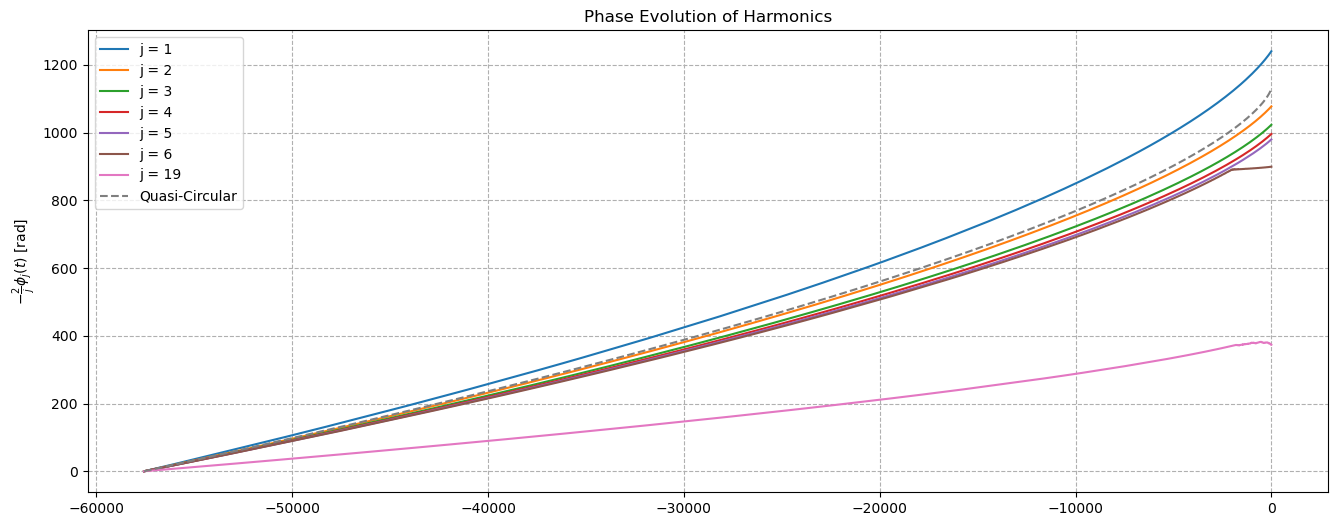

In [16]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    phase = phase - phase[0]
    plt.plot(common_time_grid, -2/j_index * phase, label=f'j = {j_index}')

plt.plot(common_time_grid, - qc_signal_phase_reco, linestyle='--', label=f'Quasi-Circular')

plt.ylabel(r'$-\frac{2}{j} \phi_j(t)$ [rad]')
plt.title('Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

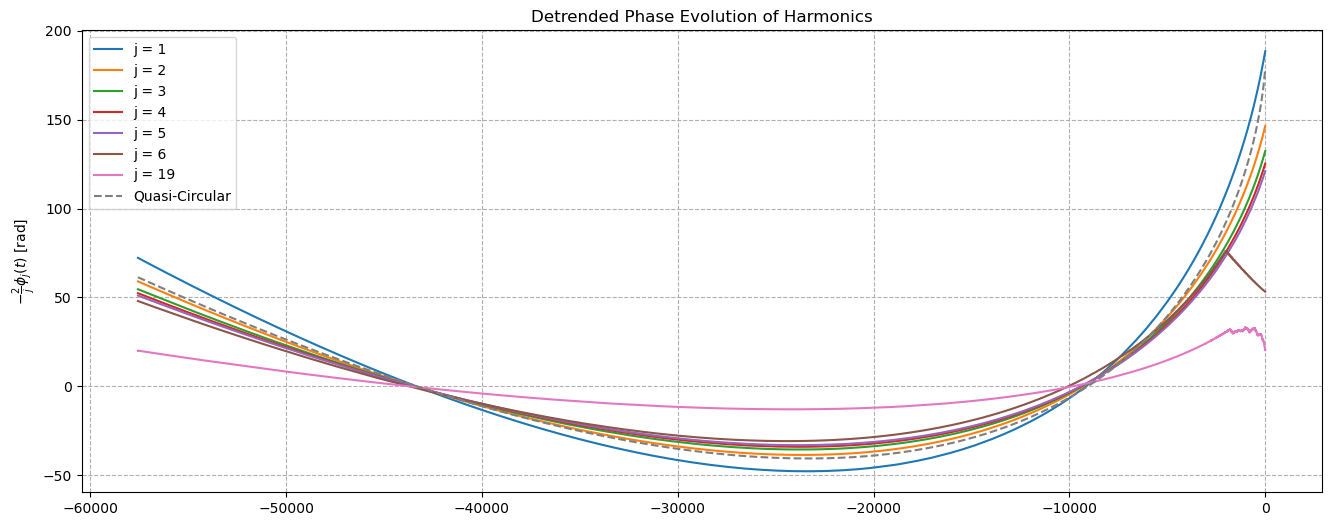

In [17]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    phase = phase - phase[0]
    plt.plot(common_time_grid, -2/j_index * detrend(phase), label=f'j = {j_index}')

plt.plot(common_time_grid, - detrend(qc_signal_phase_reco), linestyle='--', label=f'Quasi-Circular')

plt.ylabel(r'$-\frac{2}{j} \phi_j(t)$ [rad]')
plt.title('Detrended Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

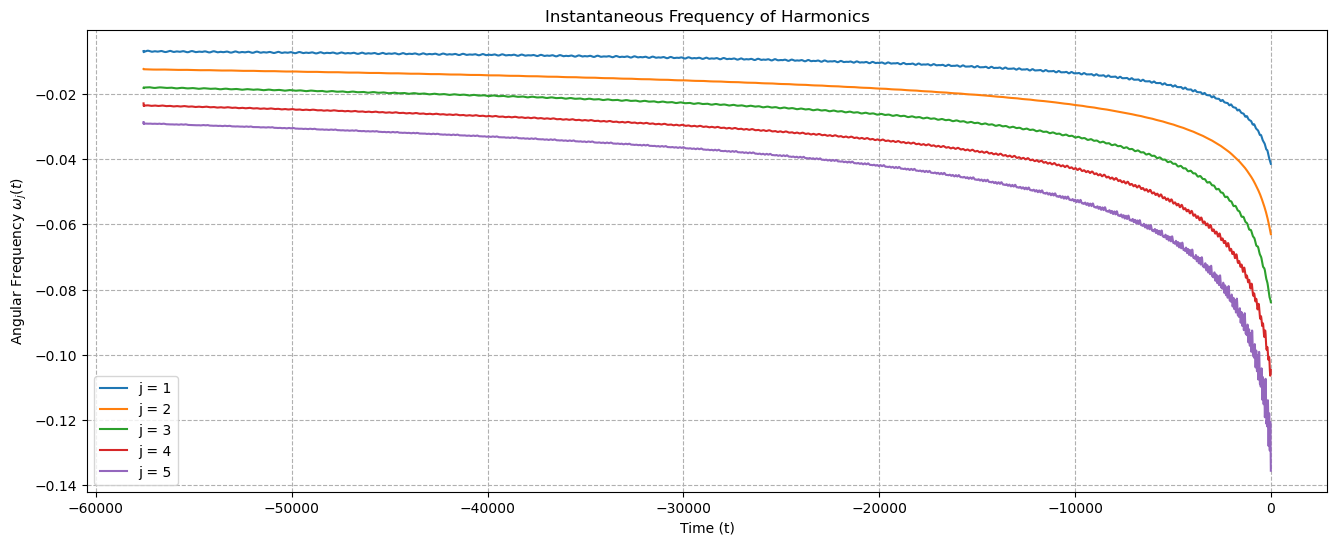

In [35]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    if j_index == 19 or j_index == 6:
        continue
    phase = np.unwrap(np.angle(waveform))
    omega = np.gradient(phase, dt)
    plt.plot(common_time_grid, omega, label=f'j = {j_index}')
plt.ylabel('Angular Frequency $\omega_j(t)$')
plt.title('Instantaneous Frequency of Harmonics')
plt.xlabel('Time (t)')
plt.legend()
plt.grid(True, which="both", ls="--")

In [19]:
def calculate_l2_error(h_original, h_recon):
    integrand_diff = np.abs(h_original - h_recon)**2
    integrand_orig = np.abs(h_original)**2
    numerator = np.sum(integrand_diff) * delta_t
    denominator = np.sum(integrand_orig) * delta_t
    return 0.5 * (numerator / denominator)

raw_basis_vectors = Vt[:5, :]
raw_errors = []

for i in range(50):
    original_waveform = X_waveform[i, :]
    
    coeffs_raw = np.dot(original_waveform, raw_basis_vectors.conj().T)
    recon_raw = np.dot(coeffs_raw, raw_basis_vectors)
    raw_errors.append(calculate_l2_error(original_waveform, recon_raw))

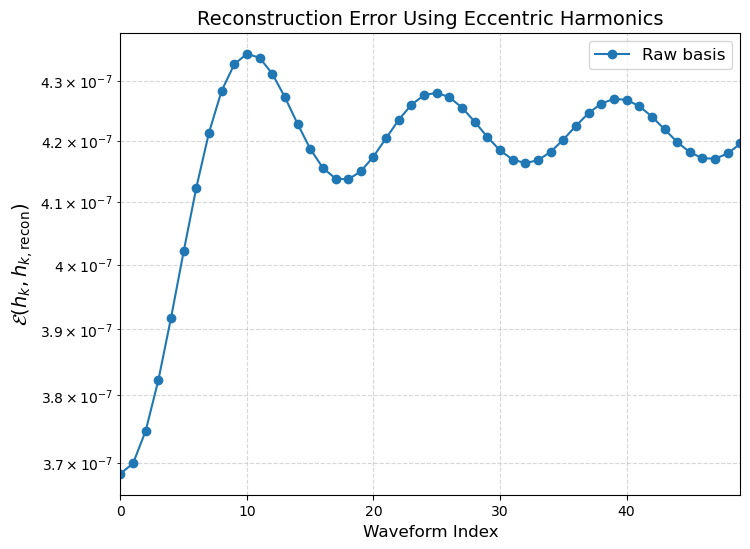

In [20]:
plt.figure(figsize=(8, 6))
plt.semilogy(range(50), raw_errors, 'o-', label='Raw basis', color='C0')
plt.xlabel('Waveform Index', fontsize=12)
plt.ylabel(r'$\mathcal{E}(h_k, h_{k, \text{recon}})$', fontsize=14)
plt.title('Reconstruction Error Using Eccentric Harmonics', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
# plt.ylim(bottom=1e-6)
plt.xlim(0, 50 - 1)
plt.show()

# Computing $\phi_{22}^{\text{avg}}$ from the integration of the average of (2,2) mode angular frequency, $\omega_{22}$ (which in turn is obtained from taking average of the interpolants of extrema of raw $\omega_{22}$)

In [21]:
ref_signal_amp = np.abs(ref_signal)
ref_signal_phase = np.unwrap(np.angle(ref_signal))

ref_signal_amp_spline = CubicSpline(ref_signal.sample_times / t0, ref_signal_amp)
ref_signal_phase_spline = CubicSpline(ref_signal.sample_times / t0, ref_signal_phase)

ref_signal_amp_reco = ref_signal_amp_spline(common_time_grid)
ref_signal_phase_reco = ref_signal_phase_spline(common_time_grid)

ref_signal_phase_reco = ref_signal_phase_reco - ref_signal_phase_reco[0]

ref_signal_reco = ref_signal_amp_reco * np.exp(1j * ref_signal_phase_reco)

In [22]:
h_22 = ref_signal_reco
dt = np.abs(common_time_grid[1] - common_time_grid[0])
phase_22 = np.unwrap(np.angle(h_22))
omega_22 = np.gradient(phase_22, dt)
omega_orb = omega_22 / 2.0

max_indices = argrelextrema(omega_orb, np.greater)[0]
min_indices = argrelextrema(omega_orb, np.less)[0]

t_p = common_time_grid[max_indices]
omega_orb_p = omega_orb[max_indices]

t_a = common_time_grid[min_indices]
omega_orb_a = omega_orb[min_indices]

sort_p = np.argsort(t_p)
t_p = t_p[sort_p]
omega_orb_p = omega_orb_p[sort_p]

sort_a = np.argsort(t_a)
t_a = t_a[sort_a]
omega_orb_a = omega_orb_a[sort_a]

spline_p = CubicSpline(t_p, omega_orb_p)
spline_a = CubicSpline(t_a, omega_orb_a)

omega_orb_p_cont = spline_p(common_time_grid)
omega_orb_a_cont = spline_a(common_time_grid)

trend, detrended_data = detrend_data(common_time_grid, omega_orb)

omega_orb_avg = (omega_orb_p_cont + omega_orb_a_cont) / 2.0

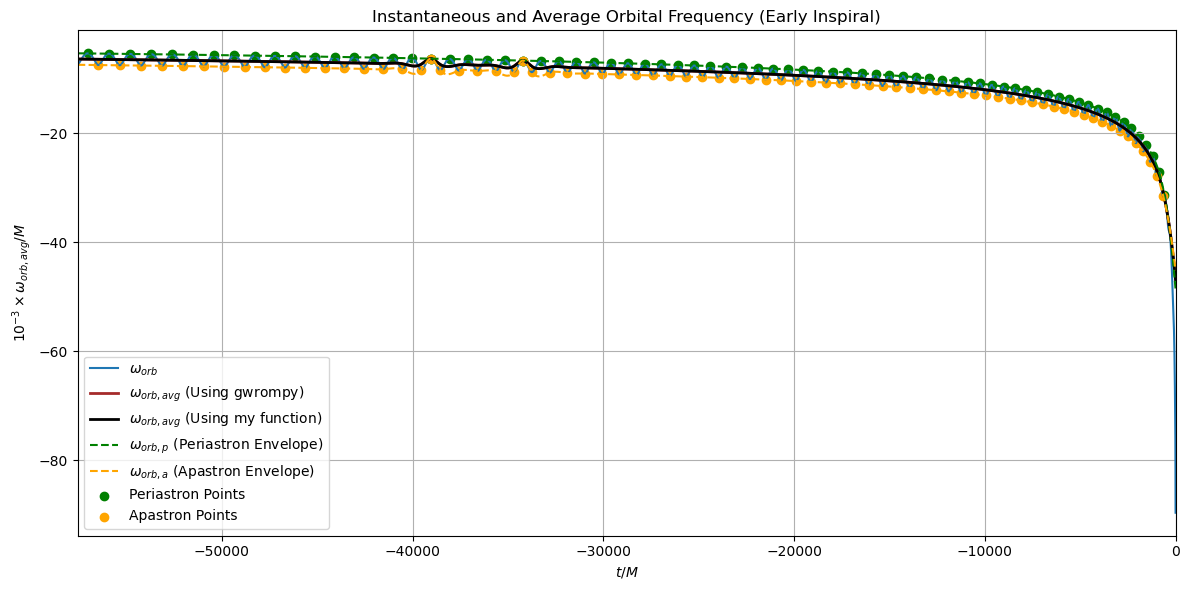

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(common_time_grid, omega_orb * 1e3, label=r'$\omega_{orb}$')
plt.plot(common_time_grid, trend * 1e3, label=r'$\omega_{orb,avg}$ (Using gwrompy)', color='brown', linewidth=2)

plt.plot(common_time_grid, omega_orb_avg * 1e3, label=r'$\omega_{orb,avg}$ (Using my function)', color='black', linewidth=2)
plt.plot(common_time_grid, omega_orb_p_cont * 1e3, label=r'$\omega_{orb,p}$ (Periastron Envelope)', linestyle='--', color='green')
plt.plot(common_time_grid, omega_orb_a_cont * 1e3, label=r'$\omega_{orb,a}$ (Apastron Envelope)', linestyle='--', color='orange')
plt.scatter(common_time_grid[max_indices], omega_orb[max_indices] * 1e3, color='green', marker='o', label='Periastron Points')
plt.scatter(common_time_grid[min_indices], omega_orb[min_indices] * 1e3, color='orange', marker='o', label='Apastron Points')

plt.xlabel(r'$t/M$')
plt.ylabel(r'$10^{-3} \times \omega_{orb, avg}/M$')
plt.title('Instantaneous and Average Orbital Frequency (Early Inspiral)')
plt.xlim(common_time_grid[0], common_time_grid[-1])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

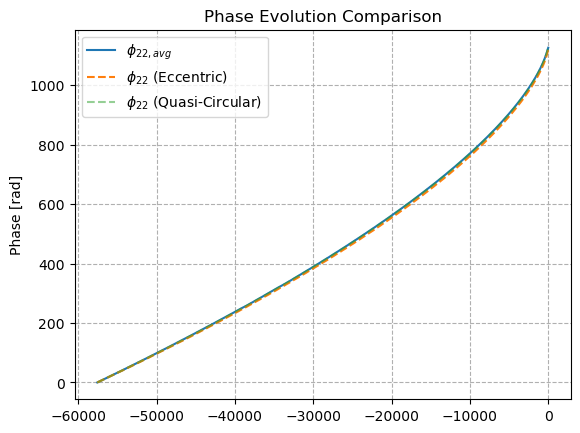

In [24]:
phi_22_avg = np.cumsum(2 * omega_orb_avg * dt)

plt.plot(common_time_grid, -phi_22_avg, label=r'$\phi_{22, avg}$')
plt.plot(common_time_grid, -ref_signal_phase_reco, linestyle='--', label=r'$\phi_{22}$ (Eccentric)')
plt.plot(common_time_grid, -qc_signal_phase_reco, linestyle='--', label=r'$\phi_{22}$ (Quasi-Circular)', alpha=0.5)
plt.ylabel('Phase [rad]')
plt.title('Phase Evolution Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")

# Computing $\phi_{22}^{\prime \text{ } \text{avg}}$ = $\phi_{22}^{\text{circ}}$ + $\phi_{\text{res}}$. And $\phi_{\text{res}}$ is obatined from taking average of the interpolants of extremas of $\Delta \phi_1 = \phi_{22} - \phi_{22}^{\text{circ}}$

In [25]:
delta_phi_1 = ref_signal_phase_reco - qc_signal_phase_reco

delta_phi_1_trend, phi_res = detrend_data(common_time_grid, delta_phi_1)

phi_22_prime_avg = qc_signal_phase_reco + phi_res

Finding a maxima without spline fit


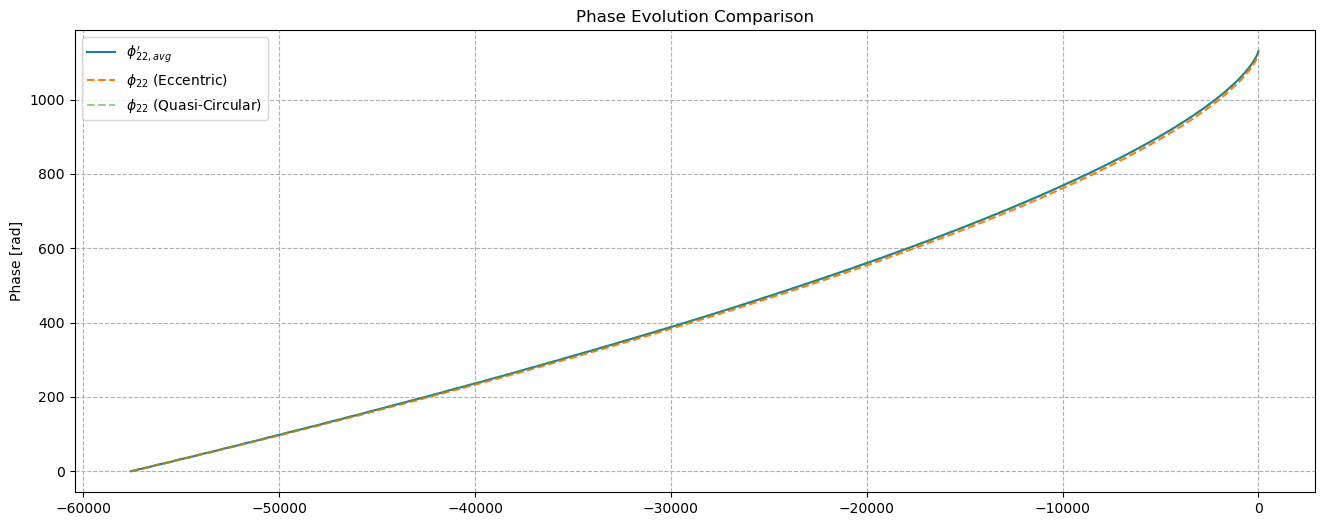

In [26]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, -phi_22_prime_avg, label=r'$\phi_{22, avg}^{\prime}$')
plt.plot(common_time_grid, -ref_signal_phase_reco, linestyle='--', label=r'$\phi_{22}$ (Eccentric)')
plt.plot(common_time_grid, -qc_signal_phase_reco, linestyle='--', label=r'$\phi_{22}$ (Quasi-Circular)', alpha=0.5)
plt.ylabel('Phase [rad]')
plt.title('Phase Evolution Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Check this

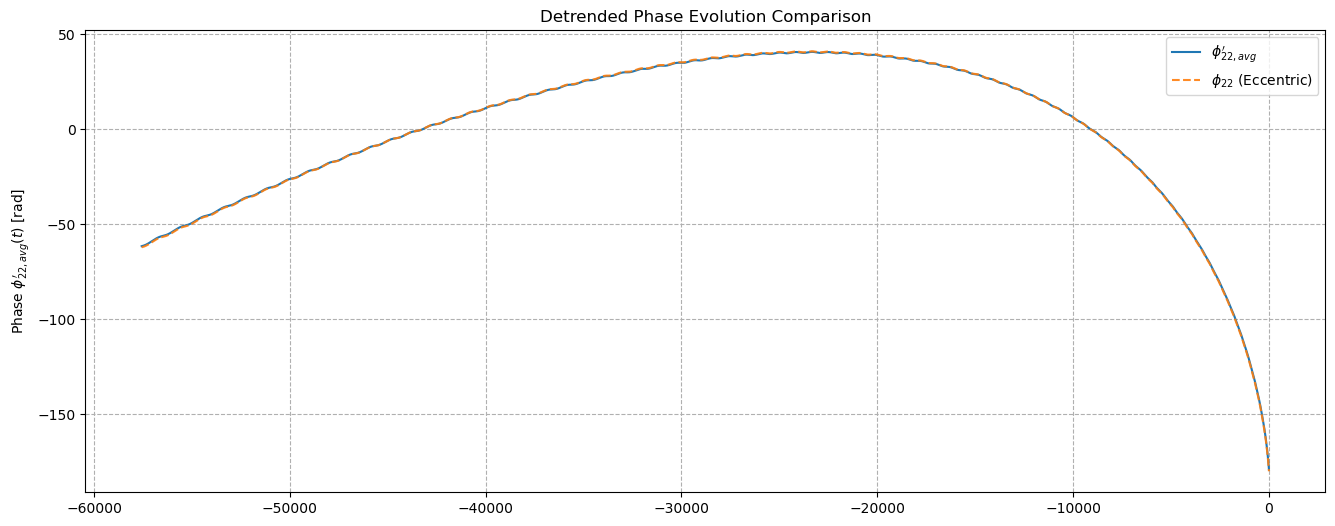

In [27]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, detrend(phi_22_prime_avg), label=r'$\phi_{22, avg}^{\prime}$')
plt.plot(common_time_grid, detrend(ref_signal_phase_reco), linestyle='--', alpha=0.9, label=r'$\phi_{22}$ (Eccentric)')
plt.ylabel('Phase $\phi_{22, avg}^{\prime}(t)$ [rad]')
plt.title('Detrended Phase Evolution Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Computing $2\phi^{\text{avg}}_{\text{orb}}$, which come from $\phi^{\text{avg}}_{\text{orb}} = \int x^{3/2} dt$

In [28]:
x = orb_vars['x'].data

x_spline = CubicSpline(orb_vars['x'].sample_times / t0, x)
x_reco = x_spline(common_time_grid)

phi_avg_orb = 2 * np.cumsum(x_reco ** (3/2)) * dt

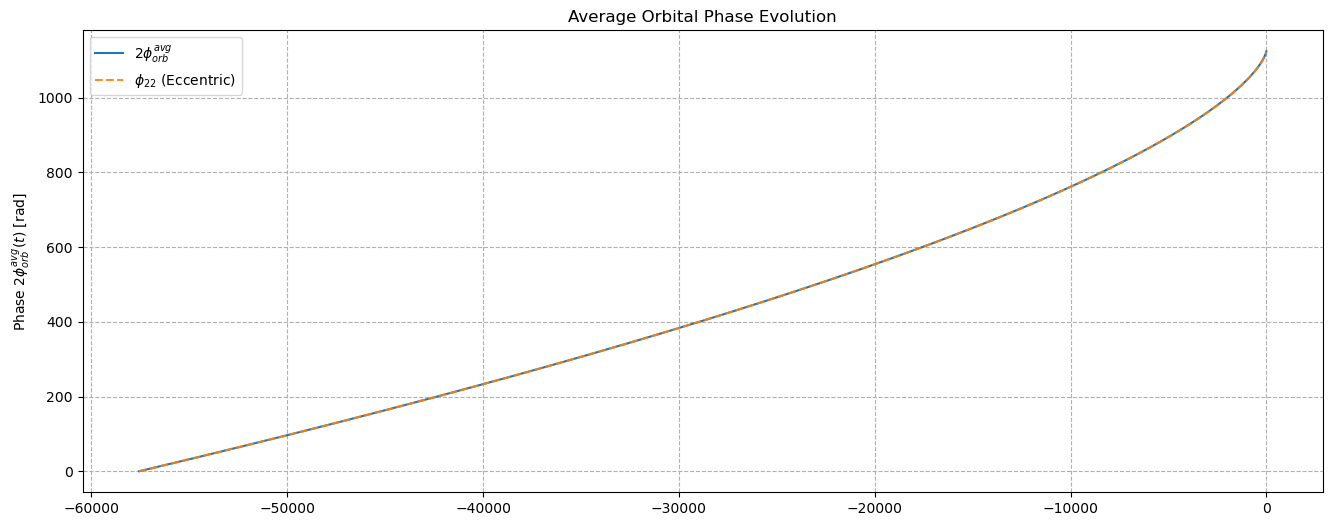

In [29]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, phi_avg_orb, label=r'$2\phi_{orb}^{avg}$')
plt.plot(common_time_grid, - ref_signal_phase_reco, linestyle='--', alpha=0.9, label=r'$\phi_{22}$ (Eccentric)')
plt.ylabel('Phase $2\phi_{orb}^{avg}(t)$ [rad]')
plt.title('Average Orbital Phase Evolution')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

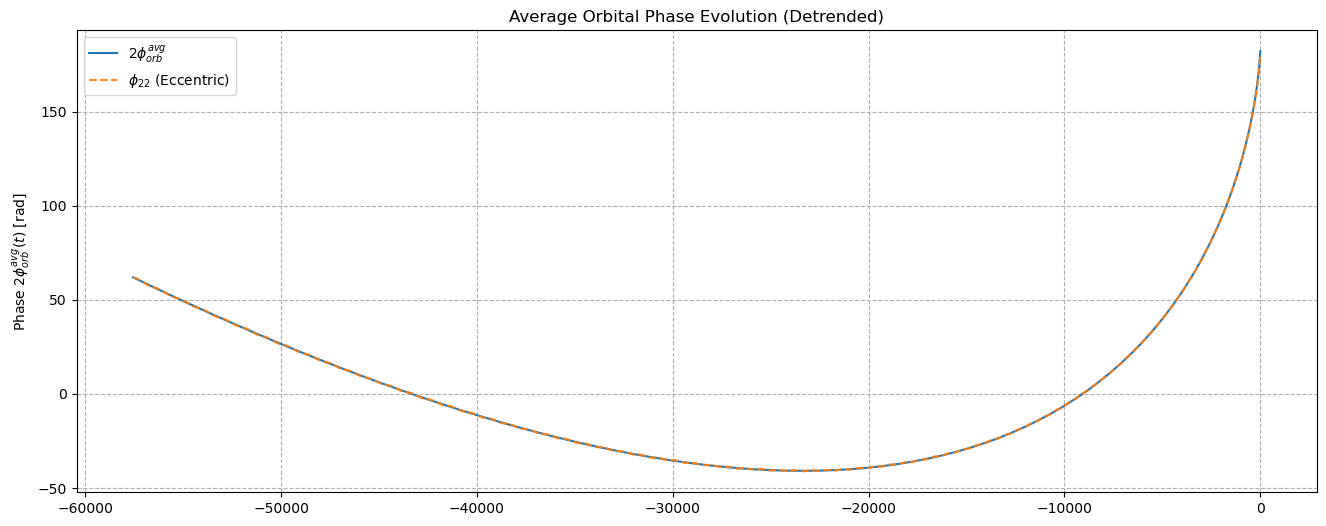

In [30]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, detrend(phi_avg_orb), label=r'$2\phi_{orb}^{avg}$')
plt.plot(common_time_grid, - detrend(ref_signal_phase_reco), linestyle='--', alpha=0.9, label=r'$\phi_{22}$ (Eccentric)')
plt.ylabel('Phase $2\phi_{orb}^{avg}(t)$ [rad]')
plt.title('Average Orbital Phase Evolution (Detrended)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Computing the evolution of $l - \phi^{\text{avg}}_{\text{orb}}$.

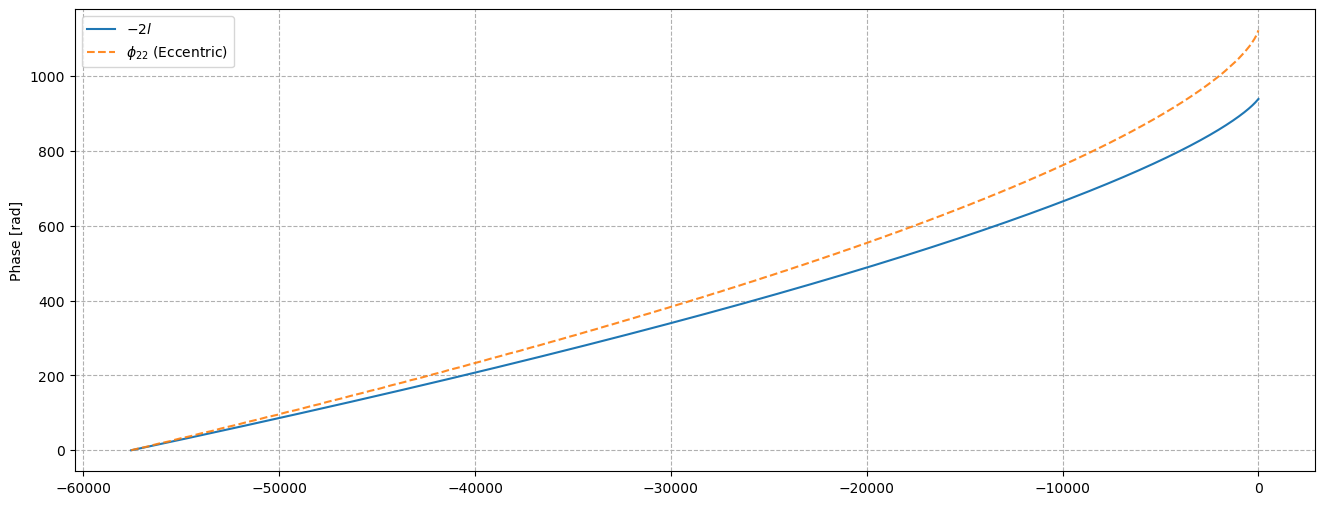

In [31]:
l = orb_vars['l']

l_spline = CubicSpline(orb_vars['l'].sample_times / t0, l)
l_reco = l_spline(common_time_grid)
l_reco -= l_reco[0]

secular_periastron_advance = l_reco - phi_avg_orb / 2

plt.figure(figsize=(16, 6))
# plt.plot(common_time_grid, -secular_periastron_advance, label=r'$l - \phi_{orb}^{avg}/2$')
plt.plot(common_time_grid, 2*l_reco, label=r'$-2l$')
plt.plot(common_time_grid, - ref_signal_phase_reco, linestyle='--', alpha=0.9, label=r'$\phi_{22}$ (Eccentric)')
plt.ylabel('Phase [rad]')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

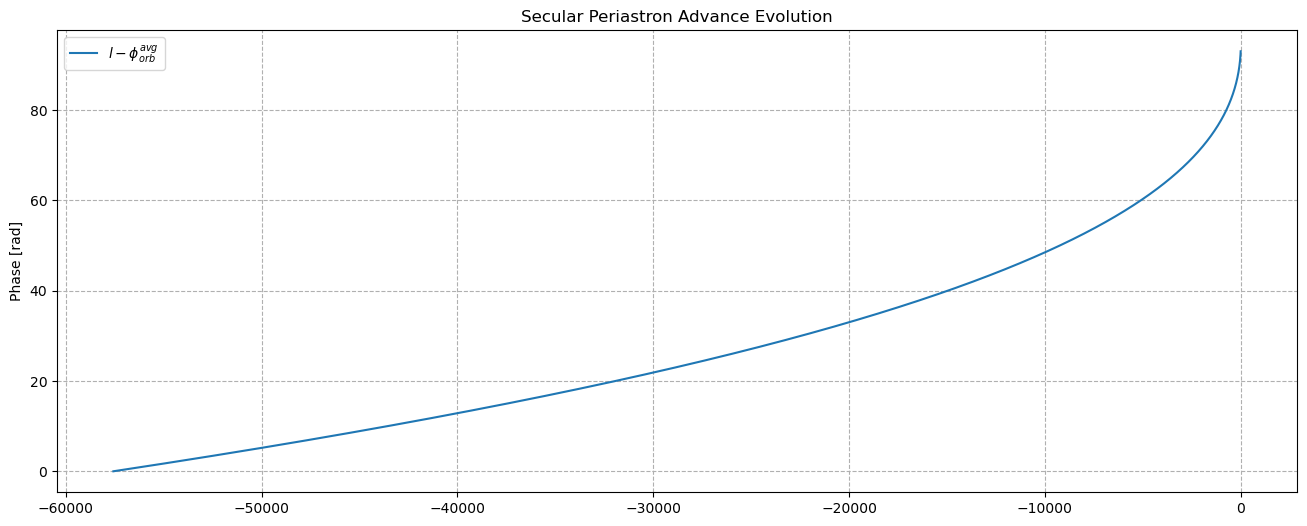

In [32]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, -secular_periastron_advance, label=r'$l - \phi_{orb}^{avg}$')
plt.ylabel('Phase [rad]')
plt.title('Secular Periastron Advance Evolution')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

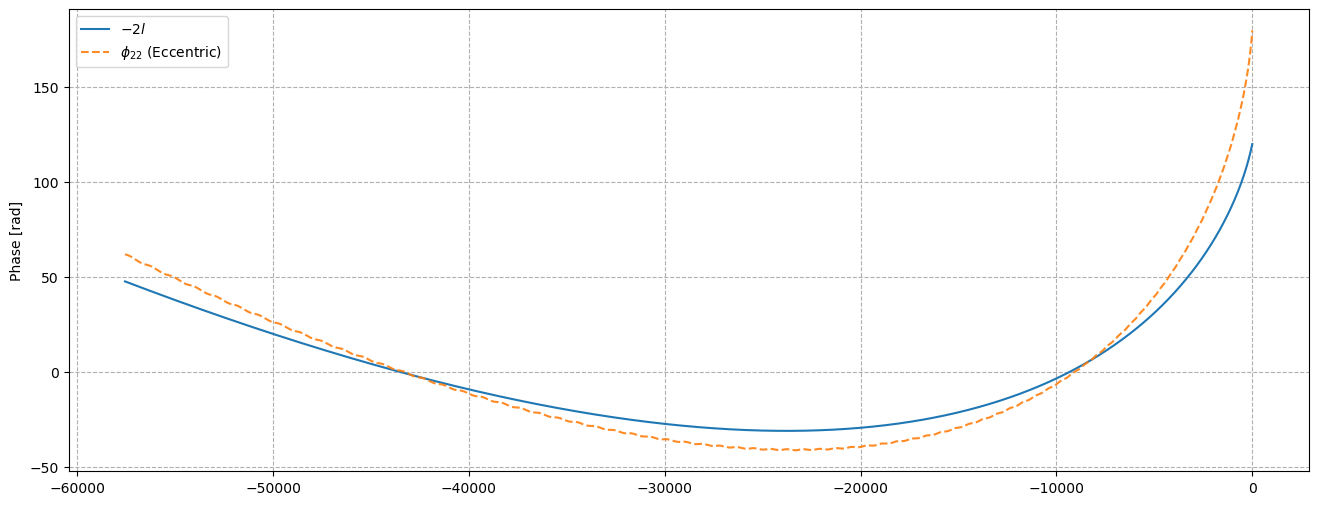

In [33]:
plt.figure(figsize=(16, 6))
plt.plot(common_time_grid, detrend(2*l_reco), label=r'$-2l$')
plt.plot(common_time_grid, - detrend(ref_signal_phase_reco), linestyle='--', alpha=0.9, label=r'$\phi_{22}$ (Eccentric)')
plt.ylabel('Phase [rad]')
plt.legend()
plt.grid(True, which="both", ls="--")